In [ ]:
!pip install geopandas ipywidgets pyproj requests rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.9 MB/s eta 0:00:00


# Lab 1: Python & Geospatial Data Mastery


Demonstrate mastery of Python fundamentals (data types, loops, functions).

Apply Python to handle and analyze geospatial data.

Work with real-world geospatial datasets using GeoPandas, Shapely, and Rasterio.

Practice writing clear, reproducible, and well-documented code.





# Section 1: Python Fundamentals Refresher


Basic Data Structures
Create a Python dictionary that represents the population of 5 U.S. states. Write a loop to print each state and its population in the format:
State: X, Population: Y.

In [ ]:
state_population= {
    "Maryland":6309380,
    "Tennessee":7227750,
    "Florida" :23400000,
    "Wisconsin":5893718,
    "New Mexico":2121164,
}
for state, population in state_population.items():
  print(f"State: {state}, Population: {population}")

State: Maryland, Population: 6309380
State: Tennessee, Population: 7227750
State: Florida, Population: 23400000
State: Wisconsin, Population: 5893718
State: New Mexico, Population: 2121164


List Comprehension & Filtering
From your dictionary above, create a list of states with a population greater than 5 million using a list comprehension.

In [ ]:
large_states = [state for state, population in state_population.items() if population > 5000000]
print(large_states)


['Maryland', 'Tennessee', 'Florida', 'Wisconsin']


Functions & Error Handling
Write a function safe_divide(a, b) that divides two numbers but returns "undefined" if division by zero is attempted. Demonstrate it with examples.

In [ ]:
safe_divide(10,0)
safe_divide(0,5)

NameError: name 'safe_divide' is not defined

# Section 2: Vector Data with GeoPandas

Loading Shapefiles
Load a Natural Earth shapefile (countries) using GeoPandas. Print the number of countries and list the first 10 country names.

In [ ]:
import geopandas as gpd
world = gpd.read_file("https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip")

print("Number of countries:", len(world))

print("First 10 countries:")
print(world.columns)


print(world["ADMIN"].head(10).tolist())

Number of countries: 258
First 10 countries:
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)
['Indonesia', 'Malaysia', 'Chile', 'Bolivia', 'Peru', 'Argentina', 'Dhekelia Sovereign Base Area', 'Cyprus', 'India', 'China']


Attribute Queries
Using the countries dataset, select all countries in South America. How many are there?

In [ ]:
import geopandas as gpd
world = gpd.read_file("https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip")
print(world.columns)

sa_countries = world[world['CONTINENT'] == 'South America']
print("Number of countries in South America:", len(sa_countries))

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)
Number of countries in South America: 15


Spatial Query
Select all countries that border Brazil and display their names.

In [ ]:
import geopandas as gpd


world = gpd.read_file("/content/ne_10m_admin_0_countries.shp")


brazil = world[world['ADMIN'] == 'Brazil']


brazil_neighbors = world[world.geometry.buffer(0.01).intersects(brazil.geometry.iloc[0].buffer(0.01))]


brazil_neighbors = brazil_neighbors[brazil_neighbors['ADMIN'] != 'Brazil']

print("Countries bordering Brazil:")
print(brazil_neighbors['ADMIN'].tolist())

/tmp/ipython-input-4066603257.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  brazil_neighbors = world[world.geometry.buffer(0.01).intersects(brazil.geometry.iloc[0].buffer(0.01))]


Countries bordering Brazil:
['Bolivia', 'Peru', 'Argentina', 'France', 'Suriname', 'Guyana', 'Uruguay', 'Colombia', 'Paraguay', 'Brazilian Island', 'Venezuela']


Coordinate Reference Systems (CRS)
Check the CRS of the dataset. Reproject it into EPSG:3857 (Web Mercator) and explain in a Markdown cell why CRS transformations matter in GIS.

In [ ]:
import geopandas as gpd

countries = gpd.read_file("/content/ne_10m_admin_0_countries.shp")

print("Original CRS:", countries.crs)

countries_3857 = countries.to_crs(epsg=3857)
print("Reprojected CRS:", countries_3857.crs)


Original CRS: EPSG:4326
Reprojected CRS: EPSG:3857


Coordinate reference systems matter in GIS because it gives us accurate distances and direction on a map to make sure that our data lines up correctly and accurately. When dealing with multiple layers, you need to make sure they are using the same coordinate system to make sure everything is where it needs to be.

Geometry Operations
Calculate the area of each country in square kilometers (after projecting to an equal-area CRS like EPSG:6933). Sort and display the top 5 largest countries.

In [ ]:
import geopandas as gpd

countries = gpd.read_file("/content/ne_10m_admin_0_countries.shp")

countries_equal_area = countries.to_crs(epsg=6933)

countries_equal_area["area_km2"] = countries_equal_area.geometry.area / 1e6  # from m² to km²

largest_countries = countries_equal_area.sort_values("area_km2", ascending=False).head(5)

print(largest_countries[["ADMIN", "area_km2"]])


                        ADMIN      area_km2
47                     Russia  1.698019e+07
175                Antarctica  1.235823e+07
155                    Canada  9.945628e+06
154  United States of America  9.464216e+06
9                       China  9.375215e+06


# Section 3: Raster Data with Rasterio

**Loading** a Raster
Load a raster dataset (e.g., a DEM or NDVI raster). Print the raster’s width, height, CRS, and resolution.

In [ ]:
import rasterio

raster ="/content/wc2.1_10m_tavg_01.tif"
with rasterio.open(raster) as src:
    width = src.width
    height = src.height
    crs = src.crs
    transform = src.transform
    resolution = src.res

    print("Width:", width)
    print("Height:", height)
    print("CRS:", crs)
    print("Resolution:", resolution)

Width: 2160
Height: 1080
CRS: EPSG:4326
Resolution: (0.16666666666666666, 0.16666666666666666)


Raster Statistics
Calculate the minimum, maximum, mean, and standard deviation of raster values. Explain what the values represent in context.

In [ ]:
import rasterio
import numpy as np

raster_path = "/content/wc2.1_10m_tavg_01.tif"

with rasterio.open(raster_path) as src:
    band1 = src.read(1)

    band1 = np.where(band1 == src.nodata, np.nan, band1)

    min_val = np.nanmin(band1)
    max_val = np.nanmax(band1)
    mean_val = np.nanmean(band1)
    std_val = np.nanstd(band1)

print("Raster Statistics")
print(f"Minimum: {min_val}")
print(f"Maximum: {max_val}")
print(f"Mean: {mean_val}")
print(f"Standard Deviation: {std_val}")


Raster Statistics
Minimum: -45.88399887084961
Maximum: 34.009498596191406
Mean: -6.736769676208496
Standard Deviation: 20.94325065612793


Raster Cropping
Clip the raster to the boundary of one country (e.g., Brazil, from the earlier vector dataset). Display the clipped raster.

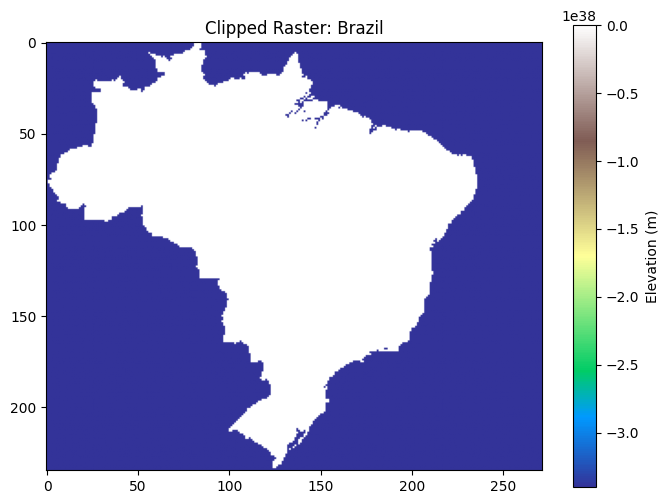

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
import matplotlib.pyplot as plt
from shapely.geometry import mapping

raster_path = "/content/wc2.1_10m_tavg_01.tif"
world = gpd.read_file("/content/ne_10m_admin_0_countries.shp")

brazil = world[world["ADMIN"] == "Brazil"]

with rasterio.open(raster_path) as src:
    brazil = brazil.to_crs(src.crs)

    geoms = [mapping(geom) for geom in brazil.geometry]

    out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

plt.figure(figsize=(8,6))
plt.imshow(out_image[0], cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Clipped Raster: Brazil")
plt.show()


# Section 4: Integrated Vector + Raster

Zonal Statistics
Using your clipped raster of Brazil and its polygon boundary, calculate the mean raster value inside the polygon (zonal mean). Explain the significance.

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
from shapely.geometry import mapping
import numpy as np
import matplotlib.pyplot as plt

raster_path = "/content/wc2.1_10m_tavg_01.tif"
world = gpd.read_file("/content/ne_10m_admin_0_countries.shp")
brazil = world[world["ADMIN"] == "Brazil"]

with rasterio.open(raster_path) as src:
    brazil_proj = brazil.to_crs(src.crs)

    geoms = [mapping(geom) for geom in brazil_proj.geometry]

    out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

    nodata = src.nodata

zonal_stats = []
for band_idx in range(out_image.shape[0]):
    band = out_image[band_idx].astype("float64")
    if nodata is not None:
        band[band == nodata] = np.nan
    min_val = np.nanmin(band)
    max_val = np.nanmax(band)
    mean_val = np.nanmean(band)
    std_val = np.nanstd(band)
    zonal_stats.append({
        "band": band_idx + 1,
        "min": float(min_val),
        "max": float(max_val),
        "mean": float(mean_val),
        "std": float(std_val)
    })

    print(f"Band {band_idx + 1}:")
    print(f"  Min: {min_val}")
    print(f"  Max: {max_val}")
    print(f"  Mean: {mean_val}")



Band 1:
  Min: 16.969249725341797
  Max: 28.99424934387207
  Mean: 25.046789917094628


This information is significant because it gives you easy information that is small and is the average for a much larger area.

Raster Masking Multiple Regions
Select all South American countries, and mask the raster so only South America remains. Display the result.

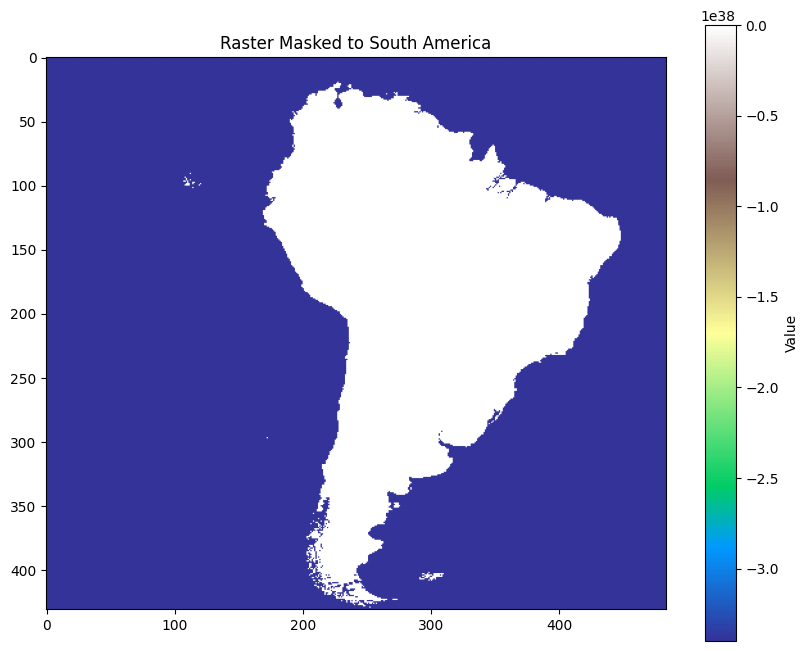

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
import matplotlib.pyplot as plt
from shapely.geometry import mapping


raster_path = "/content/wc2.1_10m_tavg_01.tif"
world = gpd.read_file("/content/ne_10m_admin_0_countries.shp")

south_america = world[world["CONTINENT"] == "South America"]

with rasterio.open(raster_path) as src:
    south_america_proj = south_america.to_crs(src.crs)

    geoms = [mapping(geom) for geom in south_america_proj.geometry]

    out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

plt.figure(figsize=(10,8))
plt.imshow(out_image[0], cmap="terrain")
plt.colorbar(label="Value")
plt.title("Raster Masked to South America")
plt.show()


# Section 5: Advanced Geospatial Python

Distance Calculation
Create a GeoDataFrame with the capitals of Brazil, Argentina, and Chile. Calculate the pairwise great-circle distance (in km) between each capital.

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import geodesic
import pandas as pd

capitals_data = {
    "country": ["Brazil", "Argentina", "Chile"],
    "capital": ["Brasília", "Buenos Aires", "Santiago"],
    "lon": [-47, -58, -70],
    "lat": [-15, -34, -33],
}

capitals_gdf = gpd.GeoDataFrame(
    capitals_data,
    geometry=gpd.points_from_xy(capitals_data["lon"], capitals_data["lat"]),
    crs="EPSG:4326"
)

print(capitals_gdf)

pairs = []
for i in range(len(capitals_gdf)):
    for j in range(i + 1, len(capitals_gdf)):
        city1 = capitals_gdf.iloc[i]
        city2 = capitals_gdf.iloc[j]
        dist_km = geodesic((city1.lat, city1.lon), (city2.lat, city2.lon)).kilometers
        pairs.append({
            "From": city1.capital,
            "To": city2.capital,
            "Distance_km": round(dist_km, 2)
        })

distances_df = pd.DataFrame(pairs)
print("\nPairwise great-circle distances (km):")
print(distances_df)


     country       capital  lon  lat         geometry
0     Brazil      Brasília  -47  -15  POINT (-47 -15)
1  Argentina  Buenos Aires  -58  -34  POINT (-58 -34)
2      Chile      Santiago  -70  -33  POINT (-70 -33)

Pairwise great-circle distances (km):
           From            To  Distance_km
0      Brasília  Buenos Aires      2377.69
1      Brasília      Santiago      3060.63
2  Buenos Aires      Santiago      1119.92


Custom Function – Automating Workflows
Write a function country_stats(country_name, raster, countries_gdf) that:

Finds the polygon for the given country.

Clips the raster to its boundary.

Returns the mean and standard deviation of raster values inside the country.
Demonstrate your function on Brazil and Argentina.

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
from shapely.geometry import mapping
import numpy as np

def country_stats(country_name, raster_path, countries_gdf):
    """
    Clip raster to the boundary of a given country and compute mean & std of raster values.

    Parameters
    ----------
    country_name : str
        Name of the country (must match the 'name' column in countries_gdf).
    raster_path : str
        Path to raster file (e.g., DEM or NDVI).
    countries_gdf : GeoDataFrame
        Vector dataset with country polygons.

    Returns
    -------
    dict
        Dictionary with country name, mean, and std of raster values.
    """

    country = countries_gdf[countries_gdf["ADMIN"] == country_name]
    if country.empty:
        raise ValueError(f"{country_name} not found in countries GeoDataFrame")

    with rasterio.open(raster_path) as src:
        country_proj = country.to_crs(src.crs)

        geoms = [mapping(geom) for geom in country_proj.geometry]

        out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        nodata = src.nodata

    data = out_image.astype("float64")
    if nodata is not None:
        data[data == nodata] = np.nan

    mean_val = float(np.nanmean(data))
    std_val = float(np.nanstd(data))

    return {"ADMIN": country_name, "mean": mean_val, "std": std_val}



countries = gpd.read_file("/content/ne_10m_admin_0_countries.shp")

raster_path = "/content/wc2.1_10m_tavg_01.tif"

brazil_stats = country_stats("Brazil", raster_path, countries)
argentina_stats = country_stats("Argentina", raster_path, countries)

print(brazil_stats)
print(argentina_stats)


{'ADMIN': 'Brazil', 'mean': 25.046789917094628, 'std': 1.4947504718231563}
{'ADMIN': 'Argentina', 'mean': 20.893960088607354, 'std': 5.760221197307876}


YOU ARE DONE!!!

**Deliverables**

Submit a Jupyter/Colab notebook (.ipynb) with:

Code for each exercise.

Markdown explanations where requested.

Include figures (maps, raster plots) where appropriate.

Code must be clean, commented, and reproducible.